In [1]:
from google.colab import drive
drive.mount('/content/drive')

FOLDER = '/content/drive/MyDrive/CPI_Research'

import tensorflow as tf
gpu = tf.config.list_physical_devices('GPU')
print("GPU detected:" , gpu if gpu else "❌ NONE — go to Runtime → Change runtime type → T4 GPU")

Mounted at /content/drive
GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import random, warnings
warnings.filterwarnings('ignore')
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

SEED = 42
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

df = pd.read_csv(f'{FOLDER}/bangladesh_MASTER_dataset.csv', index_col=0, parse_dates=True)

# Reload Session 1 results so new models append to the same table
RESULTS_PATH = f'{FOLDER}/all_model_results.csv'
results_log = pd.read_csv(RESULTS_PATH).to_dict('records')
print(f"✅ Loaded data {df.shape} + {len(results_log)} previous results")

def log_result(name, actual, pred):
    a, p = np.asarray(actual, float).ravel(), np.asarray(pred, float).ravel()
    row = {'Model': name, 'R2': round(r2_score(a,p),4),
           'RMSE': round(np.sqrt(mean_squared_error(a,p)),4),
           'MAE': round(mean_absolute_error(a,p),4),
           'MAPE': round(np.mean(np.abs((a-p)/a))*100,3)}
    results_log.append(row)
    pd.DataFrame(results_log).to_csv(RESULTS_PATH, index=False)
    print(f"✅ {name}: R²={row['R2']} RMSE={row['RMSE']} MAE={row['MAE']} MAPE={row['MAPE']}% → saved")

✅ Loaded data (317, 14) + 4 previous results


In [3]:
TRAIN_END, TEST_START, TEST_END = '2020-12-01', '2021-01-01', '2026-04-01'
LOOKBACK = 12

FEATS = ['CPI','ExchangeRate_BDT_USD','Forex_Reserves_USDmn','BroadMoney_BDTmn',
         'Brent_Oil_USD','Fed_Funds_Rate','Gold_Price_Index','FAO_Food_Index',
         'FAO_Cereals_Index','COVID_dummy','UkraineWar_dummy','BD_Unrest_dummy']

data = df.loc['2002-01-01':TEST_END, FEATS].dropna()
target_diff = data['CPI'].diff()          # predict the CHANGE
cpi_lag1    = data['CPI'].shift(1)        # to reconstruct levels later

scaler = StandardScaler().fit(data.loc[:TRAIN_END])     # TRAIN ONLY — no leakage
data_s = pd.DataFrame(scaler.transform(data), index=data.index, columns=FEATS)

X, y, y_dates, base = [], [], [], []
for i in range(LOOKBACK, len(data_s)):
    if pd.isna(target_diff.iloc[i]): continue
    X.append(data_s.iloc[i-LOOKBACK:i].values)
    y.append(target_diff.iloc[i])
    base.append(cpi_lag1.iloc[i])
    y_dates.append(data_s.index[i])

X, y, base = np.array(X), np.array(y), np.array(base)
y_dates = pd.DatetimeIndex(y_dates)

tr = y_dates <= TRAIN_END
Xtr, ytr = X[tr], y[tr]
Xte, yte, base_te = X[~tr], y[~tr], base[~tr]
dates_te = y_dates[~tr]
actual_te = base_te + yte                 # actual CPI levels for evaluation

print(f"✅ Train: {Xtr.shape} | Test: {Xte.shape} (12 months × {len(FEATS)} features each)")

✅ Train: (216, 12, 12) | Test: (64, 12, 12) (12 months × 12 features each)


In [4]:
keras.backend.clear_session()
tf.random.set_seed(SEED)

lstm = keras.Sequential([
    layers.Input(shape=(LOOKBACK, len(FEATS))),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1),
])
lstm.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

hist = lstm.fit(Xtr, ytr, validation_split=0.15, epochs=300, batch_size=16,
    callbacks=[keras.callbacks.EarlyStopping(patience=25, restore_best_weights=True)],
    verbose=0)
print(f"Stopped at epoch {len(hist.history['loss'])}")

lstm_pred = base_te + lstm.predict(Xte, verbose=0).ravel()   # change → level
log_result('LSTM', actual_te, lstm_pred)

Stopped at epoch 50
✅ LSTM: R²=0.9937 RMSE=2.6889 MAE=2.0589 MAPE=0.838% → saved


In [5]:
keras.backend.clear_session()
tf.random.set_seed(SEED)

inp = layers.Input(shape=(LOOKBACK, len(FEATS)))
x = layers.Dense(32)(inp)                                   # embed
pos = layers.Embedding(LOOKBACK, 32)(tf.range(LOOKBACK))    # positional encoding
x = x + pos
attn = layers.MultiHeadAttention(num_heads=4, key_dim=8)(x, x)
x = layers.LayerNormalization()(x + attn)
ff = layers.Dense(64, activation='relu')(x); ff = layers.Dense(32)(ff)
x = layers.LayerNormalization()(x + ff)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(1)(x)

trans = keras.Model(inp, out)
trans.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

hist = trans.fit(Xtr, ytr, validation_split=0.15, epochs=300, batch_size=16,
    callbacks=[keras.callbacks.EarlyStopping(patience=25, restore_best_weights=True)],
    verbose=0)
print(f"Stopped at epoch {len(hist.history['loss'])}")

trans_pred = base_te + trans.predict(Xte, verbose=0).ravel()
log_result('Transformer', actual_te, trans_pred)

Stopped at epoch 44
✅ Transformer: R²=0.9933 RMSE=2.7714 MAE=2.1248 MAPE=0.866% → saved


STANDINGS AFTER SESSION 2 — sorted by RMSE
                        Model     R2   RMSE    MAE  MAPE
SARIMA(2, 1, 2)x(0, 1, 1, 12) 0.9985 1.3053 0.9370 0.384
               ARIMA(3, 2, 3) 0.9940 2.6239 1.9146 0.786
                         LSTM 0.9937 2.6889 2.0589 0.838
                  Transformer 0.9933 2.7714 2.1248 0.866
     MARS-Spline-LASSO (diff) 0.9932 2.7923 2.1712 0.886
                        LASSO 0.9770 5.1332 4.3137 1.676


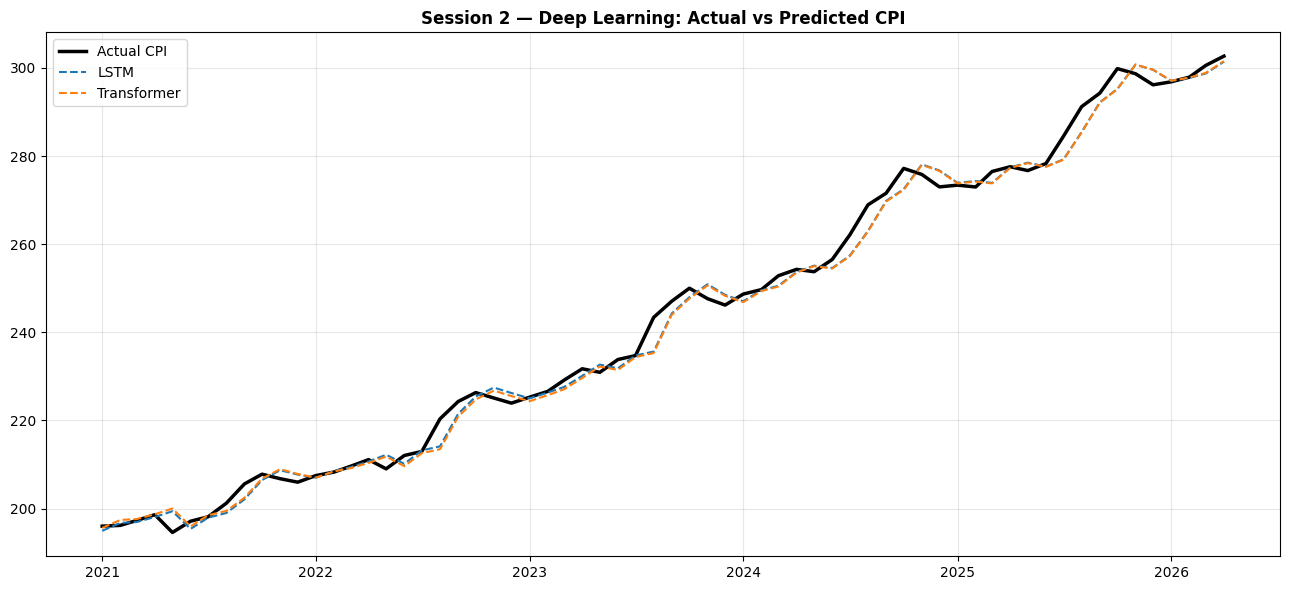

✅ Session 2 complete — results + chart saved to Drive


In [6]:
res = pd.DataFrame(results_log).sort_values('RMSE')
print("="*58); print("STANDINGS AFTER SESSION 2 — sorted by RMSE"); print("="*58)
print(res.to_string(index=False))

plt.figure(figsize=(13,6))
actual_series = pd.Series(actual_te, index=dates_te)
plt.plot(dates_te, actual_series, 'k-', lw=2.5, label='Actual CPI')
plt.plot(dates_te, lstm_pred,  '--', label='LSTM')
plt.plot(dates_te, trans_pred, '--', label='Transformer')
plt.title('Session 2 — Deep Learning: Actual vs Predicted CPI', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{FOLDER}/fig_session2_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Session 2 complete — results + chart saved to Drive")